# importing frameworks.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import numpy as np

In [4]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\Yaw\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [5]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
online_retail = fetch_ucirepo(id=352)

# data (as pandas dataframes)
X = online_retail.data.features
y = online_retail.data.targets

# metadata
print(online_retail.metadata)

# variable information
print(online_retail.variables)


{'uci_id': 352, 'name': 'Online Retail', 'repository_url': 'https://archive.ics.uci.edu/dataset/352/online+retail', 'data_url': 'https://archive.ics.uci.edu/static/public/352/data.csv', 'abstract': 'This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 541909, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': None, 'index_col': ['InvoiceNo', 'StockCode'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Oct 21 2024', 'dataset_doi': '10.24432/C5BW33', 'creators': ['Daqing Chen'], 'intro_paper': {'ID': 361, 'type': 'NATIVE', 'title': 'Data mining for the online retail industry: A case study of RFM model-based customer segmenta

# Inspecting the dataset. An overview.

In [6]:
df = online_retail.data.original #instantiating a dataframe containing the dataset.

In [7]:
print(df.head()) #viewing the first five rows of the dataset.

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [8]:
print(df.info())
print(df.describe())
#these show the various datatypes of the attributes and relevant statistical descriptions.
#

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB
None
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000

In [9]:
df.shape

(541909, 8)

In [10]:
df.isnull().sum()
#identifying the total number of rows containing an attribute that is null.
#this shows that there are 1454 rows that have a null description attribute.
# a similar issue can be raised for the customerID field.

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [11]:
df.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,10/31/2011 14:41,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


# Visualizing the raw data.

In [12]:
#summary of the quantity attribute.
# notes: this shows that there no missing quantity input as the count of quantity instances matches the total number of rows in the data.
df["Quantity"].describe()

count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

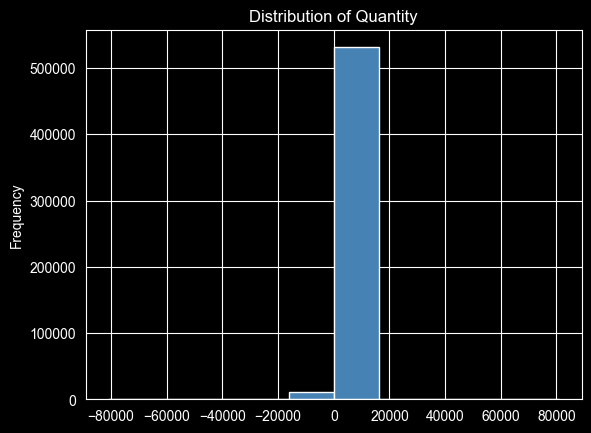

In [34]:
df["Quantity"].plot.hist(bins=10,color = 'steelblue').set_title("Distribution of Quantity")
plt.show()

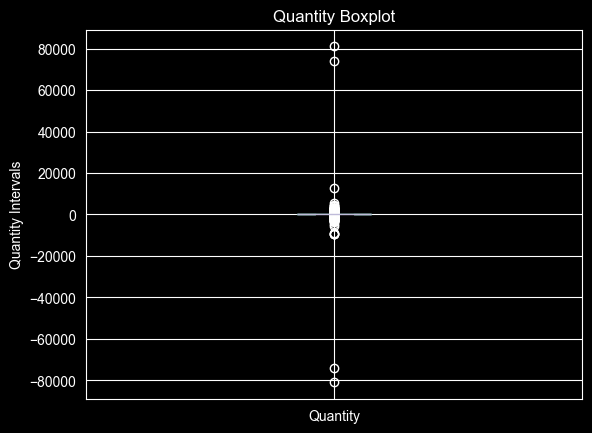

In [14]:
ax = df.boxplot(column="Quantity")
ax.set_ylabel("Quantity Intervals")
ax.set_title("Quantity Boxplot")
plt.show()


In [15]:
#summary of the unit price attribute.
# notes: from the description presented it can be seen that there is a negative unit price. for a dataset which focuses on sales, negative values should be discarded as they do not account for actual sales.
df["UnitPrice"].describe()

count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

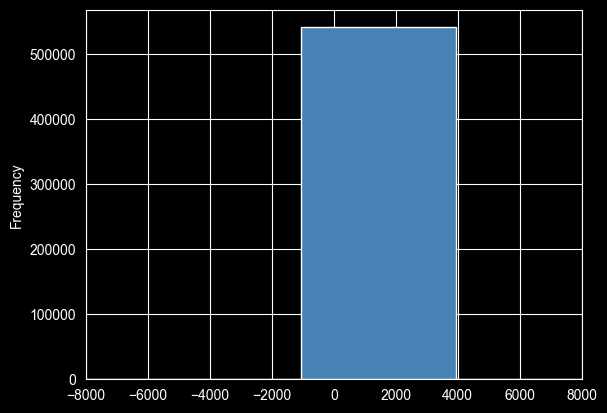

In [44]:
df["UnitPrice"].plot.hist(bins=10, color = 'steelblue')
plt.xlim(-8000,8000)
plt.show()



#notes: it can be seen that for the unit price some values lie to the left of the origin indicating that there are some refunds.

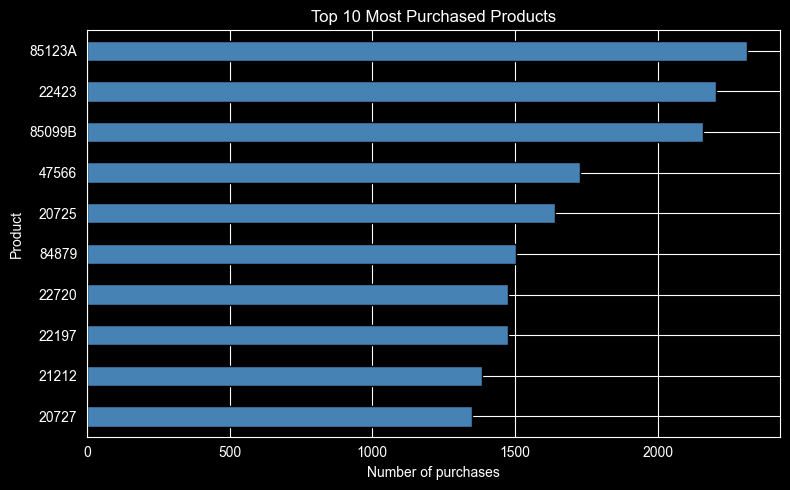

In [17]:
# Top 10 by number of rows (purchases)
top10 = df["StockCode"].value_counts().head(10)

ah = top10.plot(
    kind="barh",            # horizontal bars look nicer for long names
    figsize=(8, 5),
    color="steelblue",
    edgecolor="black"
)

ah.invert_yaxis()           # highest at top
ah.set_xlabel("Number of purchases")
ah.set_ylabel("Product")
ah.set_title("Top 10 Most Purchased Products")

plt.tight_layout()
plt.show()


In [18]:
# rows with a valid customerID
cust_transaction = df.dropna(subset=['CustomerID'])

# One transaction = one unique invoice for that customer
transaction_per_cust = (cust_transaction[['CustomerID', 'InvoiceNo']]
               .drop_duplicates()
               .groupby('CustomerID')['InvoiceNo']
               .count()
               .rename('num_invoices'))

# Quick sanity check
transaction_per_cust.head()


CustomerID
12346.0    2
12347.0    7
12348.0    4
12349.0    1
12350.0    1
Name: num_invoices, dtype: int64

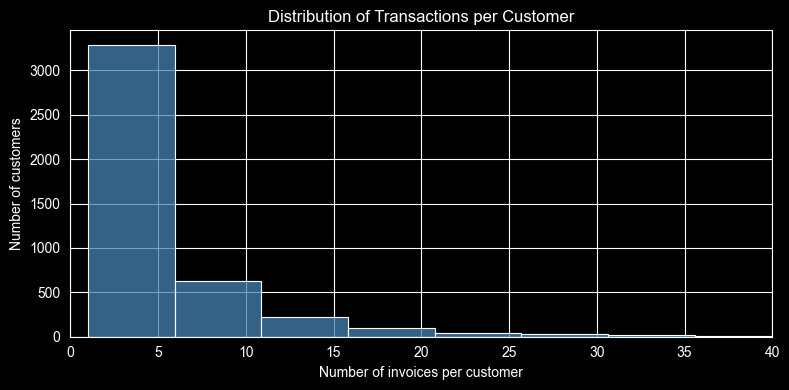

In [30]:
#plotting the distribution of invoices per customer.
plt.figure(figsize=(8,4))
sns.histplot(transaction_per_cust, bins=50, kde=False, color='steelblue')
plt.xlabel('Number of invoices per customer')
plt.ylabel('Number of customers')
plt.title('Distribution of Transactions per Customer')

plt.xlim(0,40) #limiting the range of the x-axis to at most 30 invoices.
plt.tight_layout()
plt.show()

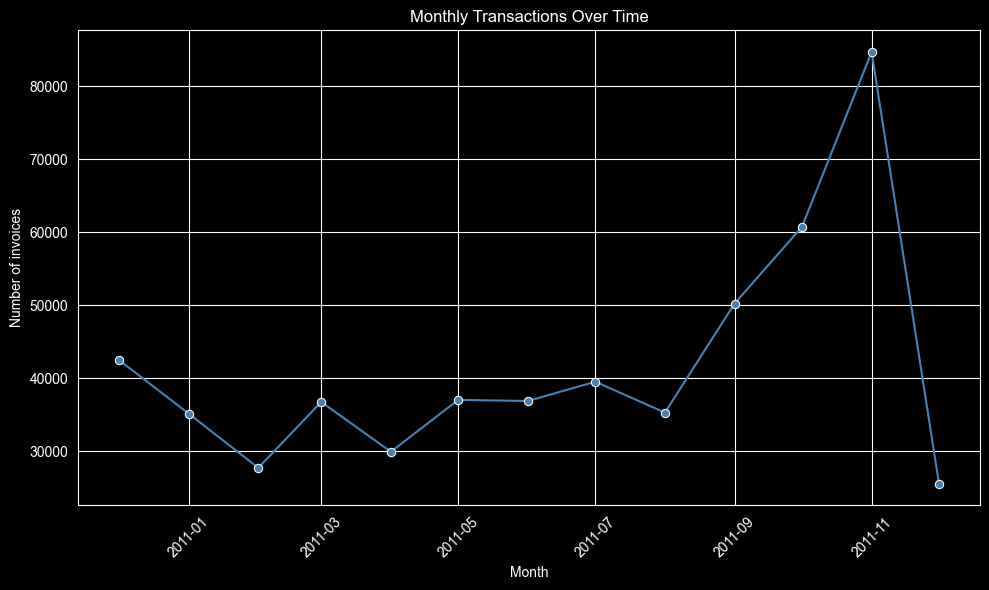

In [40]:
#since invoice date and time is stored as a string, first convert that to the datatime datatype.
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
transaction_per_month = (df[['InvoiceMonth', 'InvoiceNo']].groupby(
    'InvoiceMonth')['InvoiceNo'].count())

transaction_per_month.index = transaction_per_month.index.to_timestamp()

#plotting the monthly transaction counts
plt.figure(figsize=(10,6))
sns.lineplot(x=transaction_per_month.index, y=transaction_per_month.values, marker='o', color = 'steelblue')
plt.xlabel('Month')
plt.ylabel('Number of invoices')
plt.title('Monthly Transactions Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Data Preprocessing and cleaning

In [45]:
#removing cancellations from the data frame.
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [46]:
df.shape

(532621, 9)

In [47]:
df.head()
df.info()


<class 'pandas.DataFrame'>
Index: 532621 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   InvoiceNo     532621 non-null  str           
 1   StockCode     532621 non-null  str           
 2   Description   531167 non-null  str           
 3   Quantity      532621 non-null  int64         
 4   InvoiceDate   532621 non-null  datetime64[us]
 5   UnitPrice     532621 non-null  float64       
 6   CustomerID    397924 non-null  float64       
 7   Country       532621 non-null  str           
 8   InvoiceMonth  532621 non-null  period[M]     
dtypes: datetime64[us](1), float64(2), int64(1), period[M](1), str(4)
memory usage: 40.6 MB


In [48]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12


In [49]:
#checking for the presence of data from countries aside from the United Kingdom.
df['Country'].unique()

<StringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
                 'EIRE',          'Switzerland',                'Spain',
               'Poland',             'Portugal',                'Italy',
              'Belgium',            'Lithuania',                'Japan',
              'Iceland',      'Channel Islands',              'Denmark',
               'Cyprus',               'Sweden',              'Finland',
              'Austria',              'Bahrain',               'Israel',
               'Greece',            'Hong Kong',            'Singapore',
              'Lebanon', 'United Arab Emirates',         'Saudi Arabia',
       'Czech Republic',               'Canada',          'Unspecified',
               'Brazil',                  'USA',   'European Community',
                'Malta',                  'RSA']
Length: 38, dtype: str

In [64]:
#removing all rows which contain data from other countries.
df = df[df['Country'] == 'United Kingdom']
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12,2011-12-09 12:31:00,1.95,15804.0,United Kingdom,2011-12
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,2011-12-09 12:49:00,2.95,13113.0,United Kingdom,2011-12
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,2011-12-09 12:49:00,1.25,13113.0,United Kingdom,2011-12
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,2011-12-09 12:49:00,8.95,13113.0,United Kingdom,2011-12
541893,581586,20685,DOORMAT RED RETROSPOT,10,2011-12-09 12:49:00,7.08,13113.0,United Kingdom,2011-12


In [66]:
#removing all quantities less than zero. Ensuring there are only fulfilled orders.

df= df[df['Quantity'] > 0]

In [67]:
df['Quantity'].unique()

array([    6,     8,     2,    32,     3,     4,    80,    48,    64,
          10,    12,   120,    24,    96,    23,     5,     1,    36,
          50,    40,   100,   192,   432,   144,   288,    16,    20,
           9,   128,    25,    30,    28,     7,    56,    72,   200,
         600,   480,    14,    18,    11,    33,    13,    70,   252,
          60,   216,   384,    27,    15,    22,    19,    17,    21,
          34,    47,   108,    52,    75,   270,    42,   240,    90,
         320,  1824,   204,    69,   160,  2880,  1400,    39,    26,
          31,    82,    78,    97,    98,    35,    57,   110,   720,
         156,   324,    38,    37,    49,    95,    29,    41,   402,
         378,   150,   300,    54,   104,    67,   258,    66,    44,
          55,    46,    99,    61,   408,   972,   208,  1008,  1000,
         250,  1394,   400,    79,    84,   272,   113,    45,   106,
          68,   267,   115,    65,  1728,    53,    76,   460,    71,
          43,   213,

In [68]:
df.shape

(486286, 9)

In [69]:
#removing any entry with a missing description field.

#checking for the presence of null descriptions.
df_null_desc = df[df['Description'].isna() | (df['Description'].isnull()) | (df['Description'] == '')]

In [71]:
df_null_desc.count()

InvoiceNo       592
StockCode       592
Description       0
Quantity        592
InvoiceDate     592
UnitPrice       592
CustomerID        0
Country         592
InvoiceMonth    592
dtype: int64

In [73]:
df_null_desc

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom,2010-12
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom,2010-12
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,2010-12
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,2010-12
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,2010-12
...,...,...,...,...,...,...,...,...,...
533712,581103,22689,NaN,4,2011-12-07 11:58:00,0.0,NaN,United Kingdom,2011-12
535326,581203,23406,NaN,15,2011-12-07 18:31:00,0.0,NaN,United Kingdom,2011-12
535332,581209,21620,NaN,6,2011-12-07 18:35:00,0.0,NaN,United Kingdom,2011-12
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom,2011-12


In [74]:
# rows with null Description and very large quantity
suspect_null_desc = df_null_desc[df_null_desc['Quantity'] > 56]
suspect_null_desc


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth
7187,536995,35951,NaN,57,2010-12-03 15:29:00,0.0,NaN,United Kingdom,2010-12
7191,536999,21421,NaN,110,2010-12-03 15:32:00,0.0,NaN,United Kingdom,2010-12
7194,537002,21651,NaN,70,2010-12-03 15:33:00,0.0,NaN,United Kingdom,2010-12
13263,537430,85215,NaN,120,2010-12-06 16:05:00,0.0,NaN,United Kingdom,2010-12
20037,538004,22114,NaN,144,2010-12-09 12:11:00,0.0,NaN,United Kingdom,2010-12
...,...,...,...,...,...,...,...,...,...
404391,571674,23702,NaN,100,2011-10-18 13:22:00,0.0,NaN,United Kingdom,2011-10
440210,574518,21174,NaN,63,2011-11-04 13:42:00,0.0,NaN,United Kingdom,2011-11
453998,575505,POST,NaN,800,2011-11-10 10:29:00,0.0,NaN,United Kingdom,2011-11
453999,575506,C2,NaN,150,2011-11-10 10:30:00,0.0,NaN,United Kingdom,2011-11


In [75]:
suspect_null_desc.sort_values('Quantity', ascending=False).head(20)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth
74614,542504,37413,NaN,5568,2011-01-28 12:03:00,0.0,NaN,United Kingdom,2011-01
74615,542505,79063D,NaN,2560,2011-01-28 12:04:00,0.0,NaN,United Kingdom,2011-01
82795,543258,84611B,NaN,1287,2011-02-04 16:06:00,0.0,NaN,United Kingdom,2011-02
52262,540699,POST,NaN,1000,2011-01-11 09:32:00,0.0,NaN,United Kingdom,2011-01
136537,547966,DOT,NaN,1000,2011-03-28 15:49:00,0.0,NaN,United Kingdom,2011-03
80665,543051,79062D,NaN,960,2011-02-03 10:15:00,0.0,NaN,United Kingdom,2011-02
205991,554857,POST,NaN,800,2011-05-27 10:08:00,0.0,NaN,United Kingdom,2011-05
453998,575505,POST,NaN,800,2011-11-10 10:29:00,0.0,NaN,United Kingdom,2011-11
326552,565556,POST,NaN,750,2011-09-05 12:14:00,0.0,NaN,United Kingdom,2011-09
336309,566316,23306,NaN,682,2011-09-12 10:07:00,0.0,NaN,United Kingdom,2011-09


In [80]:
suspect_null_desc.sort_values('UnitPrice', ascending=False).head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth
7187,536995,35951,NaN,57,2010-12-03 15:29:00,0.0,NaN,United Kingdom,2010-12
7191,536999,21421,NaN,110,2010-12-03 15:32:00,0.0,NaN,United Kingdom,2010-12
7194,537002,21651,NaN,70,2010-12-03 15:33:00,0.0,NaN,United Kingdom,2010-12
13263,537430,85215,NaN,120,2010-12-06 16:05:00,0.0,NaN,United Kingdom,2010-12
20037,538004,22114,NaN,144,2010-12-09 12:11:00,0.0,NaN,United Kingdom,2010-12
21778,538129,84497,NaN,79,2010-12-09 15:55:00,0.0,NaN,United Kingdom,2010-12
21780,538131,17091A,NaN,84,2010-12-09 15:56:00,0.0,NaN,United Kingdom,2010-12
22295,538160,20956,NaN,288,2010-12-09 17:18:00,0.0,NaN,United Kingdom,2010-12
30364,538861,22444,NaN,460,2010-12-14 14:04:00,0.0,NaN,United Kingdom,2010-12
52262,540699,POST,NaN,1000,2011-01-11 09:32:00,0.0,NaN,United Kingdom,2011-01


In [81]:
#with the unit price in mind it will be okay to remove all items without descriptions.
# count before
before = df.shape[0]

# drop null, NaN, and empty-string descriptions
df = df[~(df['Description'].isna() | (df['Description'].str.strip() == ''))]

# count after and how many dropped
after = df.shape[0]
dropped = before - after
print("Dropped rows with null/NaN/empty Description:", dropped)


Dropped rows with null/NaN/empty Description: 592


In [85]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12


In [86]:
df.shape

(485694, 9)

In [91]:
# rows with UnitPrice equal to 0
zero_price = df[df['UnitPrice'] == 0]

# rows with UnitPrice less than 0
neg_price = df[df['UnitPrice'] < 0]

# rows with UnitPrice zero OR less than zero
zero_or_neg = df[df['UnitPrice'] <= 0]

zero_or_neg


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth
6391,536941,22734,amazon,20,2010-12-03 12:08:00,0.0,NaN,United Kingdom,2010-12
6392,536942,22139,amazon,15,2010-12-03 12:08:00,0.0,NaN,United Kingdom,2010-12
14335,537534,85064,CREAM SWEETHEART LETTER RACK,1,2010-12-07 11:48:00,0.0,NaN,United Kingdom,2010-12
14336,537534,84832,ZINC WILLIE WINKIE CANDLE STICK,1,2010-12-07 11:48:00,0.0,NaN,United Kingdom,2010-12
14337,537534,84692,BOX OF 24 COCKTAIL PARASOLS,2,2010-12-07 11:48:00,0.0,NaN,United Kingdom,2010-12
...,...,...,...,...,...,...,...,...,...
524622,580609,22927,Amazon,1,2011-12-05 11:41:00,0.0,NaN,United Kingdom,2011-12
535325,581202,23404,check,41,2011-12-07 18:30:00,0.0,NaN,United Kingdom,2011-12
535334,581211,22142,check,14,2011-12-07 18:36:00,0.0,NaN,United Kingdom,2011-12
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom,2011-12


In [92]:
#dropping all rows with a unit price at 0 or less than zero since the store cannot sell items with a zero pound sterling unit price.

# number of rows before
before = df.shape[0]

# keep only rows with positive UnitPrice
df = df[df['UnitPrice'] > 0]

# optional: how many were removed
after = df.shape[0]
dropped = before - after
print("Dropped rows with UnitPrice <= 0:", dropped)


Dropped rows with UnitPrice <= 0: 571


In [93]:
#creating a total price column for the table.
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [94]:
df


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12,20.34
...,...,...,...,...,...,...,...,...,...,...
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12,2011-12-09 12:31:00,1.95,15804.0,United Kingdom,2011-12,23.40
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,2011-12-09 12:49:00,2.95,13113.0,United Kingdom,2011-12,23.60
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,2011-12-09 12:49:00,1.25,13113.0,United Kingdom,2011-12,30.00
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,2011-12-09 12:49:00,8.95,13113.0,United Kingdom,2011-12,214.80


# Data transformation for Association rules